# Phase 2: Exploratory Data Analysis
Goal: Understand feature distributions, correlations, and class balance before preprocessing.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv('../data/raw/Crop_recommendation.csv')

# Make sure the figures folder exists
os.makedirs('../reports/figures', exist_ok=True)

sns.set_style('whitegrid')

In [9]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


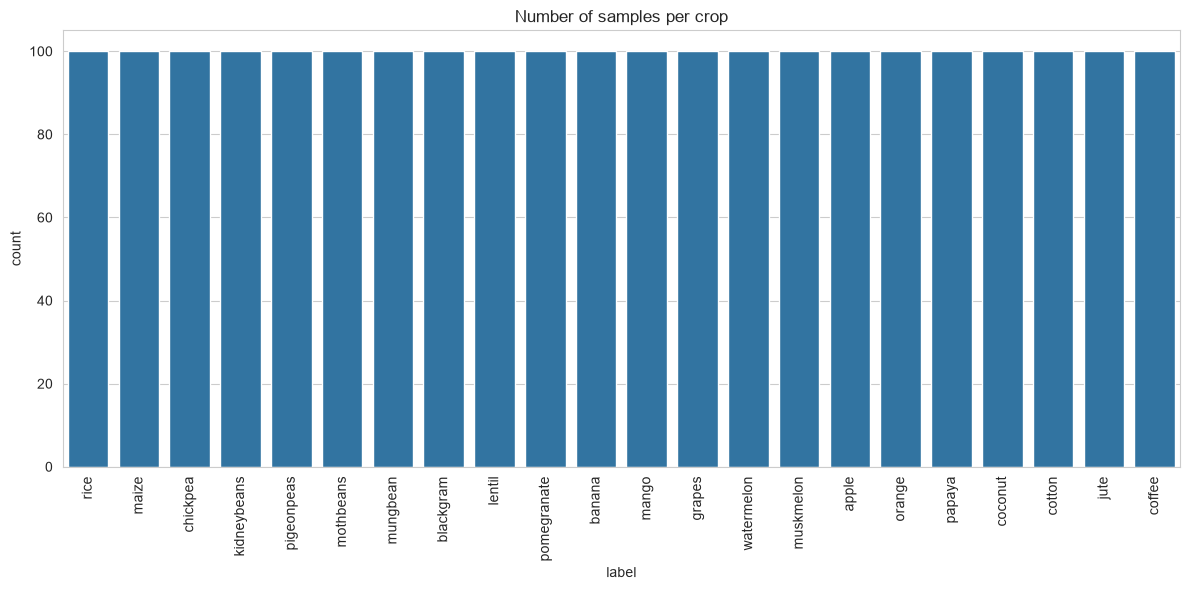

In [10]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Number of samples per crop')
plt.tight_layout()
plt.savefig('../reports/figures/class_balance.png')
plt.show()

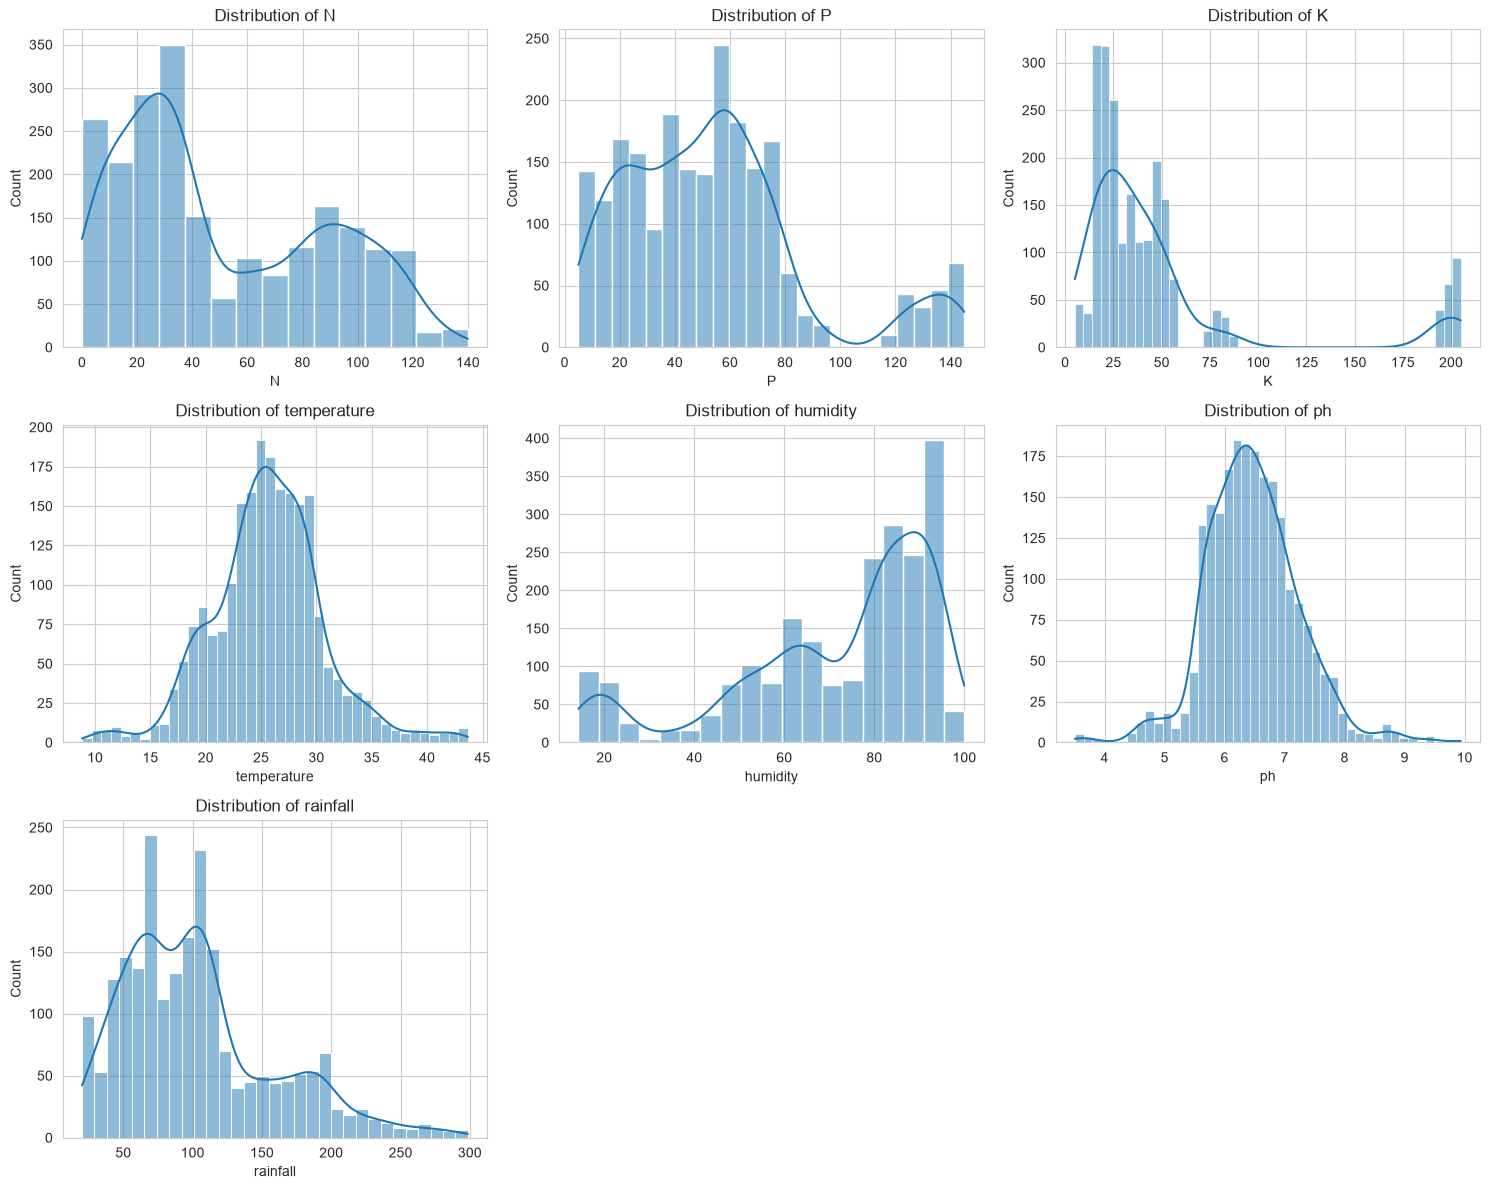

In [11]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# Hide unused subplots
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('../reports/figures/feature_distributions.png')
plt.show()

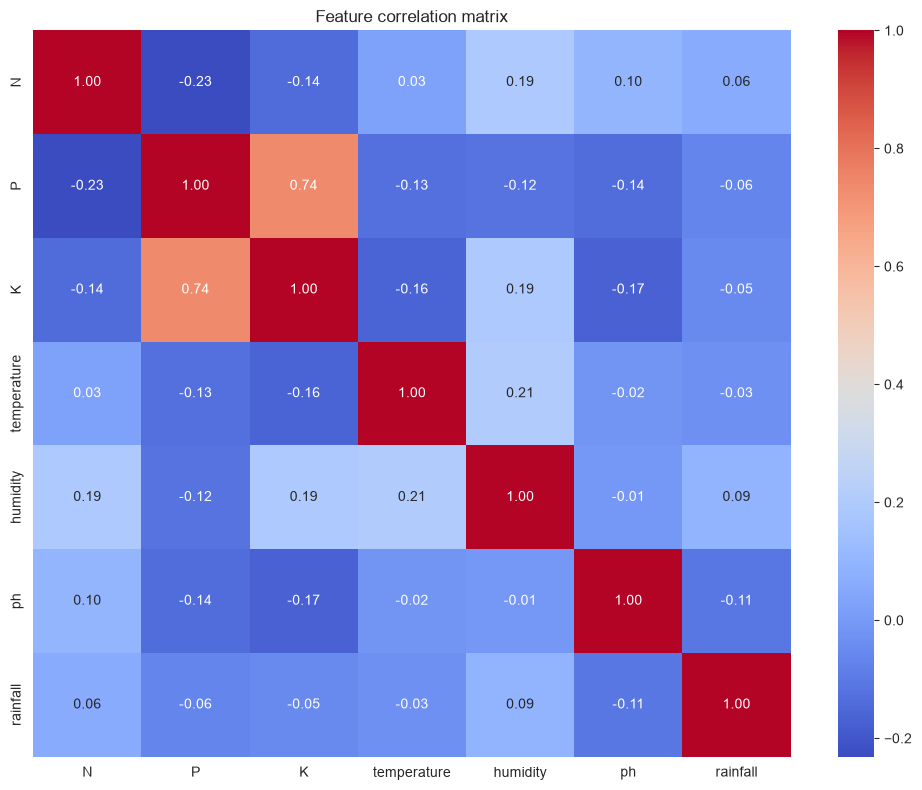

In [12]:
plt.figure(figsize=(10, 8))
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png')
plt.show()

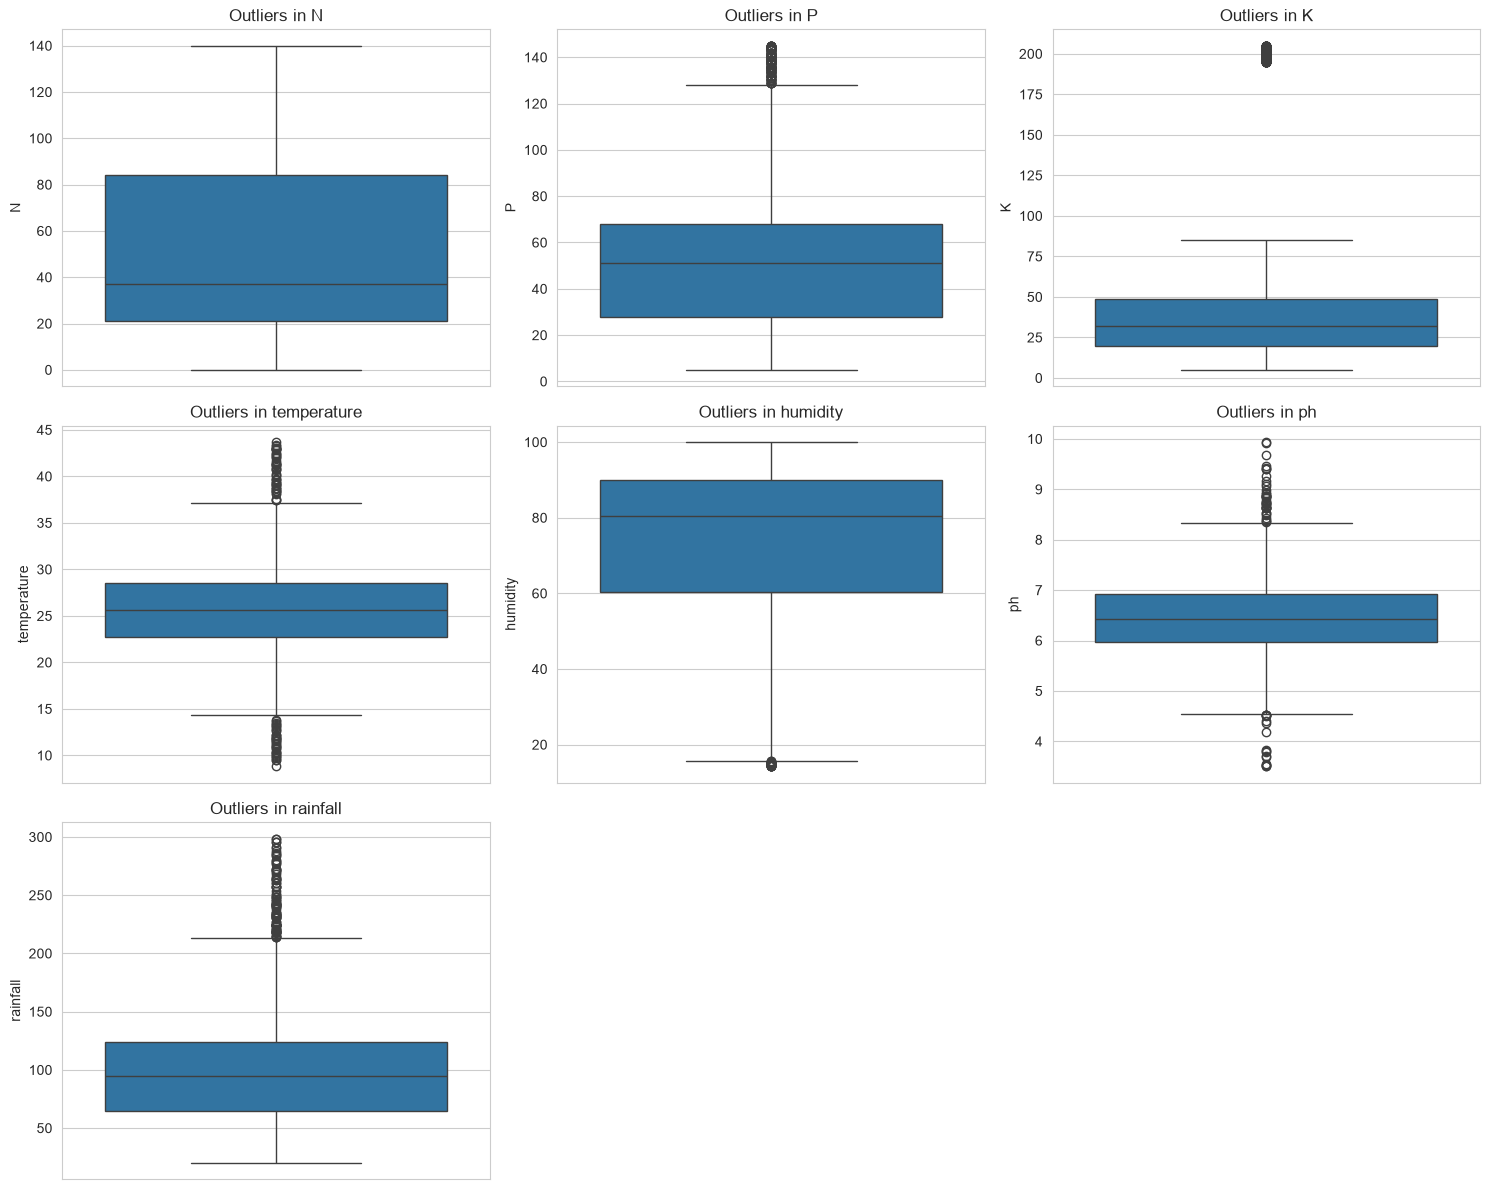

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Outliers in {col}')

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('../reports/figures/outlier_boxplots.png')
plt.show()

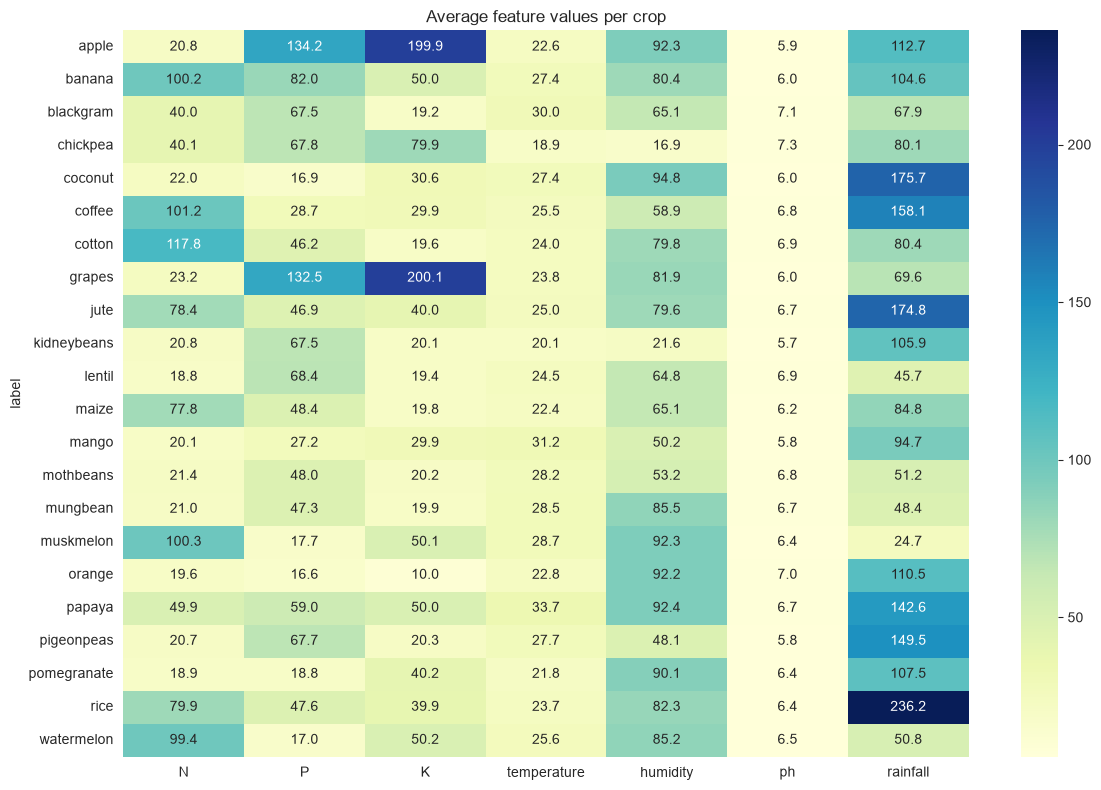

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.groupby('label')[features].mean(), annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Average feature values per crop')
plt.tight_layout()
plt.savefig('../reports/figures/feature_means_per_crop.png')
plt.show()

## Summary

- Class balance: All 22 crop classes are perfectly balanced, with 100 samples for each crop.
- Strongest correlations: Phosphorous (P) and Potassium (K) have the strongest positive correlation (0.74). Other feature correlations are weak.
- Outliers present in: P, K, temperature, humidity, pH, and rainfall contain outliers, while Nitrogen has very few or no significant outliers.
- Key insight: The dataset is clean, balanced, contains no missing values or duplicates, and is suitable for machine learning model development.